# sklearn Regression Model

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

model_dir = Path('../models')
model_dir.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.reshape(-1,1)

X_val = pd.read_csv('../data/processed/X_valid_scaled.csv')
y_val = pd.read_csv('../data/processed/y_valid.csv').values.reshape(-1,1)

## Model Selection

#### K-Nearest Neighbors (KNN)

In [59]:
#training on train data
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

with open(model_dir / 'knn.pkl', 'wb') as f:
    pickle.dump(knn, f)

print('KNN model saved to ../models/knn.pkl')

KNN model saved to ../models/knn.pkl


In [60]:
# evaluation on test output vs predict
y_pred = neighbors.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("----- Model Report -----")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

----- Model Report -----
Mean Absolute Error: 0.1389
Root Mean Squared Error: 0.2168
R2 Score: 0.7481


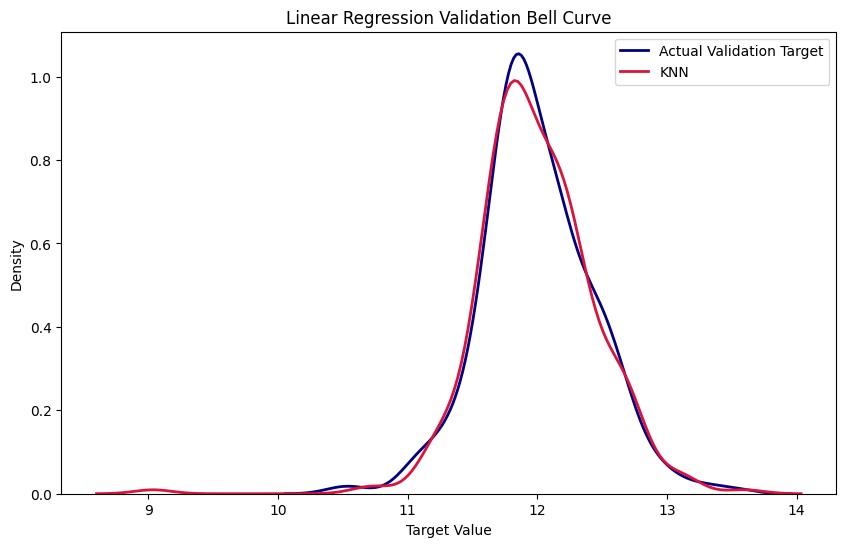

In [61]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(linear_pred), label='KNN', linewidth=2, color='crimson')
plt.title('Linear Regression Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Linear Regression

In [62]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

with open(model_dir / 'linear_regression.pkl', 'wb') as f:
    pickle.dump(linear_regression, f)

print('Linear regression model saved to ../models/linear_regression.pkl')

Linear regression model saved to ../models/linear_regression.pkl


In [63]:
linear_pred = linear_regression.predict(X_val)

linear_mae = mean_absolute_error(y_val, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_val, linear_pred))
linear_r2 = r2_score(y_val, linear_pred)

print('----- Linear Regression Report -----')
print(f'Mean Absolute Error: {linear_mae:.4f}')
print(f'Root Mean Squared Error: {linear_rmse:.4f}')
print(f'R2 Score: {linear_r2:.4f}')


----- Linear Regression Report -----
Mean Absolute Error: 0.0989
Root Mean Squared Error: 0.2325
R2 Score: 0.7102


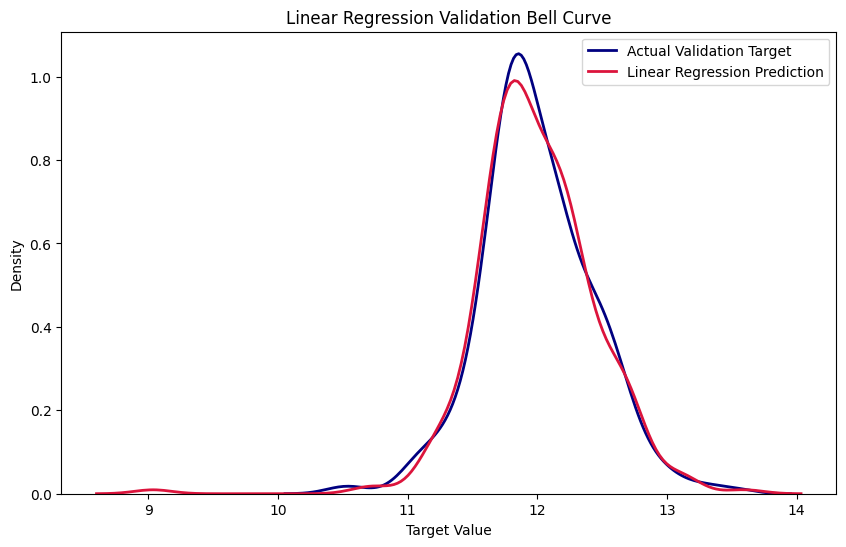

In [64]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(linear_pred), label='Linear Regression Prediction', linewidth=2, color='crimson')
plt.title('Linear Regression Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Decision Tree Regressor

In [65]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X_train, y_train)

with open(model_dir / 'decision_tree.pkl', 'wb') as f:
    pickle.dump(decision_tree, f)

print('Decision tree model saved to ../models/decision_tree.pkl')

Decision tree model saved to ../models/decision_tree.pkl


In [66]:
decision_tree_pred = decision_tree.predict(X_val)

decision_tree_mae = mean_absolute_error(y_val, decision_tree_pred)
decision_tree_rmse = np.sqrt(mean_squared_error(y_val, decision_tree_pred))
decision_tree_r2 = r2_score(y_val, decision_tree_pred)

print('----- Decision Tree Report -----')
print(f'Mean Absolute Error: {decision_tree_mae:.4f}')
print(f'Root Mean Squared Error: {decision_tree_rmse:.4f}')
print(f'R2 Score: {decision_tree_r2:.4f}')


----- Decision Tree Report -----
Mean Absolute Error: 0.1416
Root Mean Squared Error: 0.2057
R2 Score: 0.7733


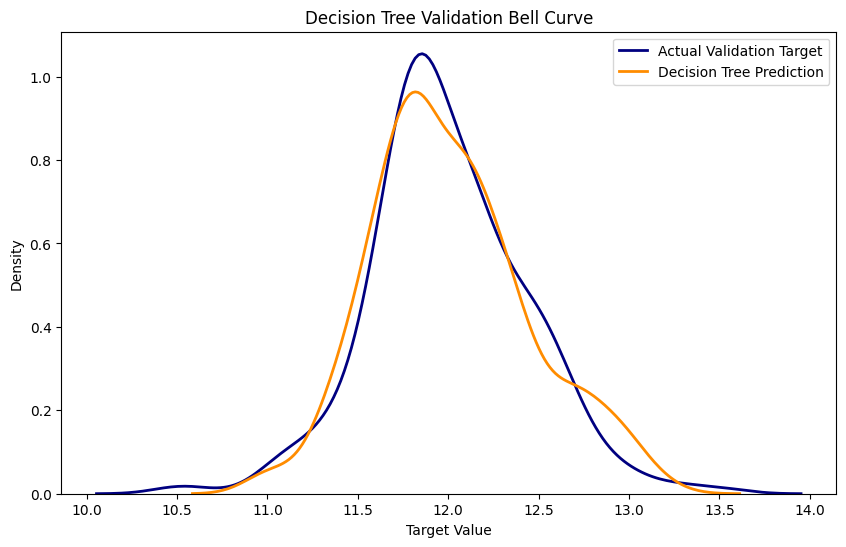

In [67]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(decision_tree_pred), label='Decision Tree Prediction', linewidth=2, color='darkorange')
plt.title('Decision Tree Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Support Vector Regressor (SVM)

In [68]:
from sklearn.svm import SVR

svm = SVR()
svm.fit(X_train, np.ravel(y_train))

with open(model_dir / 'svm.pkl', 'wb') as f:
    pickle.dump(svm, f)

print('SVM model saved to ../models/svm.pkl')

SVM model saved to ../models/svm.pkl


In [69]:
svm_pred = svm.predict(X_val)

svm_mae = mean_absolute_error(y_val, svm_pred)
svm_rmse = np.sqrt(mean_squared_error(y_val, svm_pred))
svm_r2 = r2_score(y_val, svm_pred)

print('----- SVM Report -----')
print(f'Mean Absolute Error: {svm_mae:.4f}')
print(f'Root Mean Squared Error: {svm_rmse:.4f}')
print(f'R2 Score: {svm_r2:.4f}')


----- SVM Report -----
Mean Absolute Error: 0.1286
Root Mean Squared Error: 0.2158
R2 Score: 0.7503


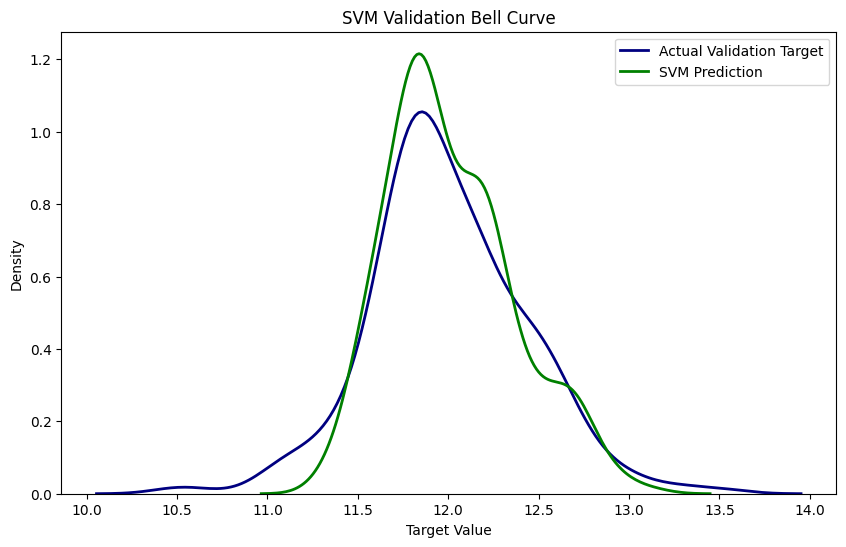

In [70]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(svm_pred), label='SVM Prediction', linewidth=2, color='green')
plt.title('SVM Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Random Forest Regressor

In [71]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(random_state=42)
random_forest.fit(X_train, np.ravel(y_train))

with open(model_dir / 'random_forest.pkl', 'wb') as f:
    pickle.dump(random_forest, f)

print('Random forest model saved to ../models/random_forest.pkl')

Random forest model saved to ../models/random_forest.pkl


In [72]:
random_forest_pred = random_forest.predict(X_val)

random_forest_mae = mean_absolute_error(y_val, random_forest_pred)
random_forest_rmse = np.sqrt(mean_squared_error(y_val, random_forest_pred))
random_forest_r2 = r2_score(y_val, random_forest_pred)

print('----- Random Forest Report -----')
print(f'Mean Absolute Error: {random_forest_mae:.4f}')
print(f'Root Mean Squared Error: {random_forest_rmse:.4f}')
print(f'R2 Score: {random_forest_r2:.4f}')


----- Random Forest Report -----
Mean Absolute Error: 0.0983
Root Mean Squared Error: 0.1487
R2 Score: 0.8815


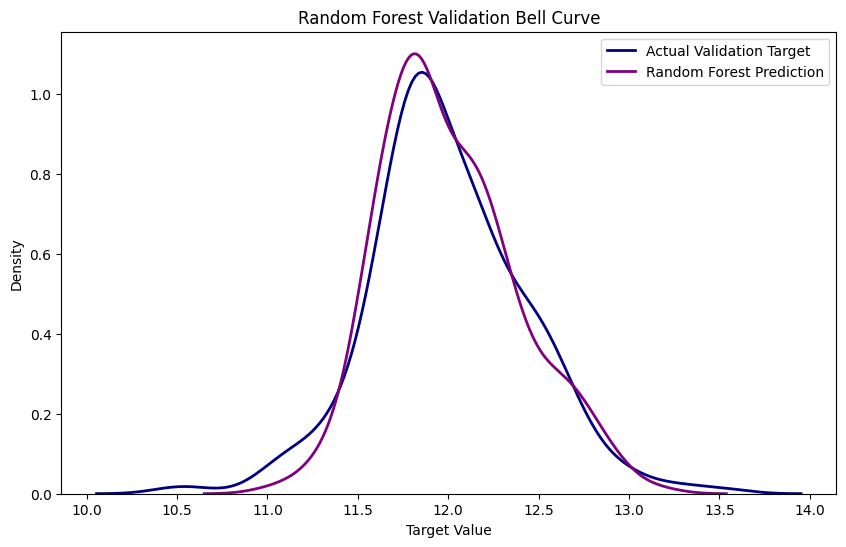

In [73]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(random_forest_pred), label='Random Forest Prediction', linewidth=2, color='purple')
plt.title('Random Forest Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Final Model Comparison

In [74]:
all_model_results = pd.DataFrame({
    'Model': ['KNN', 'Linear Regression', 'Decision Tree', 'SVM', 'Random Forest'],
    'MAE': [mae, linear_mae, decision_tree_mae, svm_mae, random_forest_mae],
    'RMSE': [rmse, linear_rmse, decision_tree_rmse, svm_rmse, random_forest_rmse],
    'R2 Score': [r2, linear_r2, decision_tree_r2, svm_r2, random_forest_r2]
})

all_model_results.sort_values(by='R2 Score', ascending=False)

,Model,MAE,RMSE,R2 Score
4,Random Forest,0.098347,0.148707,0.881498
2,Decision Tree,0.141560,0.205700,0.773259
3,SVM,0.128596,0.215841,0.750350
0,KNN,0.138920,0.216804,0.748117
1,Linear Regression,0.098885,0.232548,0.710207


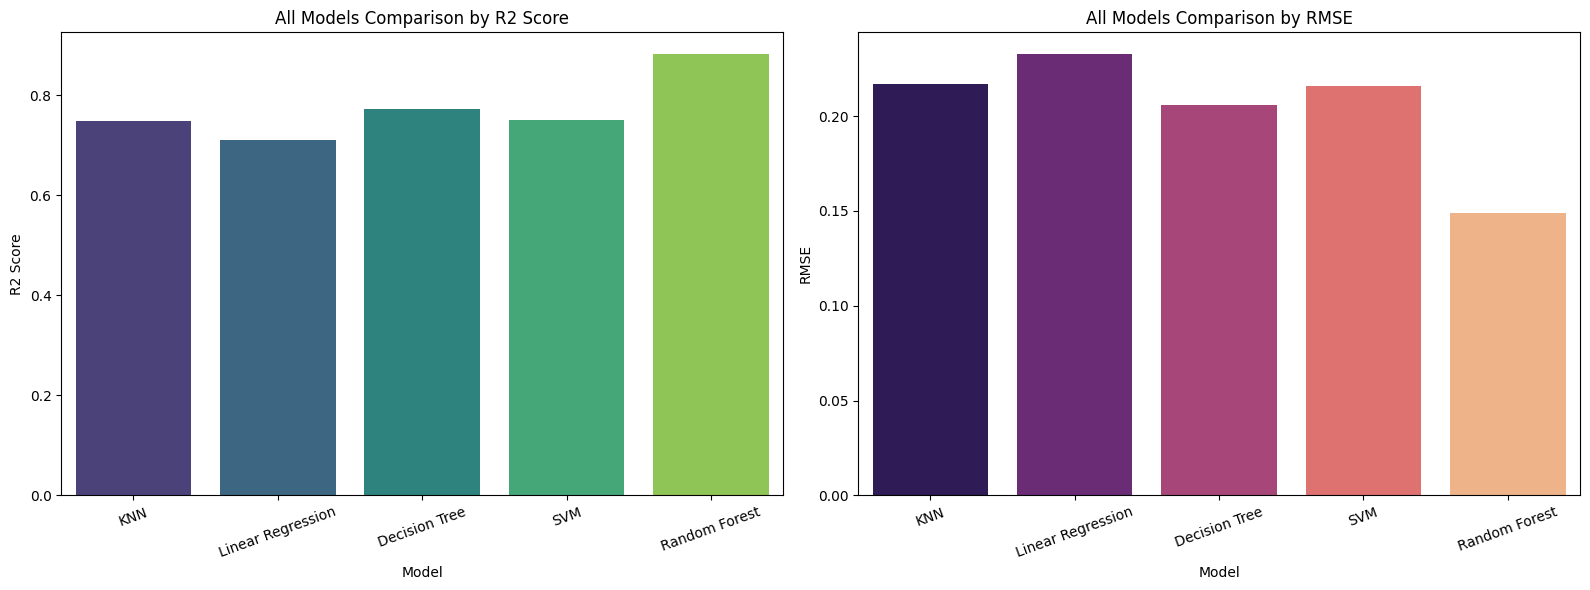

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=all_model_results, x='Model', y='R2 Score', hue='Model', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('All Models Comparison by R2 Score')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R2 Score')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=all_model_results, x='Model', y='RMSE', hue='Model', palette='magma', ax=axes[1], legend=False)
axes[1].set_title('All Models Comparison by RMSE')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()